<a href="https://colab.research.google.com/github/Rukshana-S/hiver-spotify-ai-support-agent/blob/main/01_spotify_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Hiver Spotify AI Support Agent

## Phase 1: Dataset Loading

In [8]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/Hiver_Spotify_AI/data/twcs.csv"

df = pd.read_csv(DATA_PATH)

In [9]:
df.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 7 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   tweet_id                 1048575 non-null  int64  
 1   author_id                1048575 non-null  object 
 2   inbound                  1048575 non-null  bool   
 3   created_at               1048575 non-null  object 
 4   text                     1048575 non-null  object 
 5   response_tweet_id        683860 non-null   object 
 6   in_response_to_tweet_id  767999 non-null   float64
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 49.0+ MB


In [11]:
df.isnull().sum()

,0
tweet_id,0
author_id,0
inbound,0
created_at,0
text,0
response_tweet_id,364715
in_response_to_tweet_id,280576


In [12]:
df.to_csv(
    "/content/drive/MyDrive/Hiver_Spotify_AI/processed/raw_loaded.csv",
    index=False
)

In [13]:
import pandas as pd
import numpy as np
df = pd.read_csv(DATA_PATH)

In [14]:
print(df.shape)

(1048575, 7)


In [15]:
print(df["author_id"].nunique())

273748


In [16]:
company_accounts = (
    df[df["inbound"] == False]["author_id"]
    .value_counts()
    .head(30)
)

company_accounts

,count
author_id,
AmazonHelp,79139
AppleSupport,32945
Uber_Support,21411
Delta,16372
SpotifyCares,14328
AmericanAir,14324
Tesco,11430
British_Airways,11261
comcastcares,10860


In [17]:
spotify_accounts = df[
    df["author_id"]
      .astype(str)
      .str.contains("spotify", case=False, na=False)
]["author_id"].value_counts()

spotify_accounts

,count
author_id,
SpotifyCares,14328


In [18]:
summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Unique Authors"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df["author_id"].nunique()
    ]
})

summary

,Metric,Value
0,Total Rows,1048575
1,Total Columns,7
2,Unique Authors,273748


In [19]:
summary.to_csv(
    "/content/drive/MyDrive/Hiver_Spotify_AI/processed/dataset_summary.csv",
    index=False
)

In [20]:
spotify_accounts

,count
author_id,
SpotifyCares,14328


## Phase 2: Spotify Conversation Extraction

In [21]:
spotify_company = df[df["author_id"] == "SpotifyCares"].copy()

print("Spotify company tweets:", len(spotify_company))
spotify_company.head()

Spotify company tweets: 14328


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
540,848,SpotifyCares,False,Tue Oct 31 22:28:16 +0000 2017,@115887 Hmm. Can you try restarting your devic...,849,850.0
542,851,SpotifyCares,False,Tue Oct 31 23:39:03 +0000 2017,@115887 Could you send us a DM with your accou...,NaN,849.0
544,852,SpotifyCares,False,Tue Oct 31 21:04:13 +0000 2017,"@115887 Thanks. Just to be sure, are you Free ...",850,853.0
546,854,SpotifyCares,False,Tue Oct 31 19:36:16 +0000 2017,"@115887 Hey! What device, operating system, an...",853,855.0
548,856,SpotifyCares,False,Tue Oct 31 22:25:16 +0000 2017,@115889 Got it. It's not possible at the momen...,857,858.0


In [22]:
customer_tweet_ids = (
    spotify_company["in_response_to_tweet_id"]
    .dropna()
    .astype(int)
    .unique()
)

print("Customer tweets connected to Spotify:", len(customer_tweet_ids))

Customer tweets connected to Spotify: 13969


In [23]:
spotify_customers = df[df["tweet_id"].isin(customer_tweet_ids)].copy()

print("Connected customer tweets:", len(spotify_customers))
spotify_customers.head()

Connected customer tweets: 13952


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
541,849,115887,True,Tue Oct 31 23:36:20 +0000 2017,@SpotifyCares doesn’t work and i even tried de...,851,848.0
543,850,115887,True,Tue Oct 31 21:41:37 +0000 2017,@SpotifyCares Premium &amp; when i️ have it on...,848,852.0
545,853,115887,True,Tue Oct 31 19:57:59 +0000 2017,@SpotifyCares iphone 7+ and i have the most re...,852,854.0
547,855,115887,True,Tue Oct 31 19:10:51 +0000 2017,i’m pissed my @115888 shuffle and repeat butto...,854,NaN
549,857,115889,True,Wed Nov 01 07:40:06 +0000 2017,"@SpotifyCares Yes, multiple times. No changes....",859,856.0


In [24]:
spotify_twitter = pd.concat(
    [spotify_company, spotify_customers],
    ignore_index=True
)

spotify_twitter = spotify_twitter.drop_duplicates(subset="tweet_id")

print("Total Spotify conversation tweets:", len(spotify_twitter))

Total Spotify conversation tweets: 28250


In [25]:
spotify_twitter = spotify_twitter.sort_values("created_at")

spotify_twitter.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
23618,787488,307849,True,Fri Apr 07 10:36:18 +0000 2017,@115888 (3) their playlists bc ur algorithm ca...,787487,NaN
9498,787487,SpotifyCares,False,Fri Apr 07 11:25:53 +0000 2017,@307849 Hey Will! We’ve made some improvements...,787485,787488.0
23617,787485,307849,True,Fri Apr 07 12:09:32 +0000 2017,@SpotifyCares Improvements haven't been notice...,787482,787487.0
9496,787482,SpotifyCares,False,Fri Apr 07 14:58:17 +0000 2017,@307849 We're sorry you feel that way. We appr...,"7,87,48,37,87,484",787485.0
17544,301485,187918,True,Fri Aug 11 17:05:40 +0000 2017,@SpotifyCares before I already asked about if ...,301484,NaN


In [26]:
OUTPUT_PATH = "/content/drive/MyDrive/Hiver_Spotify_AI/processed/spotify_twitter.csv"

spotify_twitter.to_csv(OUTPUT_PATH, index=False)

print("Saved to:", OUTPUT_PATH)

Saved to: /content/drive/MyDrive/Hiver_Spotify_AI/processed/spotify_twitter.csv


In [27]:
spotify_twitter["response_tweet_id"].dropna().head(10)

,response_tweet_id
23618,787487
9498,787485
23617,787482
9496,"7,87,48,37,87,484"
17544,301484
3306,301483
17543,301482
3305,301481
17542,301480
3304,301478


In [29]:
def split_responses(value):
    if pd.isna(value):
        return []
    s = str(value)
    # Remove any character that is not a digit or a comma
    cleaned_s = "".join(filter(lambda x: x.isdigit() or x == ',', s))
    if not cleaned_s: # If after cleaning, the string is empty or only commas
        return []

    response_ids = []
    for part in cleaned_s.split(","):
        part = part.strip()
        if part.isdigit(): # Check if the part consists only of digits
            response_ids.append(int(part))
    return response_ids

spotify_twitter["response_list"] = spotify_twitter["response_tweet_id"].apply(split_responses)

spotify_twitter[["tweet_id", "response_tweet_id", "response_list"]].head()

,tweet_id,response_tweet_id,response_list
23618,787488,787487,[787487]
9498,787487,787485,[787485]
23617,787485,787482,[787482]
9496,787482,"7,87,48,37,87,484","[7, 87, 48, 37, 87, 484]"
17544,301485,301484,[301484]


In [30]:
tweet_lookup = spotify_twitter.set_index("tweet_id").to_dict("index")

len(tweet_lookup)

28250

In [31]:
def build_thread(start_id):
    thread = []
    current = start_id
    visited = set()

    while current in tweet_lookup and current not in visited:
        visited.add(current)

        row = tweet_lookup[current]

        thread.append({
            "tweet_id": current,
            "author": row["author_id"],
            "inbound": row["inbound"],
            "text": row["text"]
        })

        responses = row["response_list"]

        if responses:
            current = responses[0]      # follow first reply for now
        else:
            break

    return thread

In [32]:
conversation_roots = spotify_twitter[
    (spotify_twitter["inbound"] == True) &
    (spotify_twitter["in_response_to_tweet_id"].isna())
]["tweet_id"].tolist()

print("Conversation roots:", len(conversation_roots))

Conversation roots: 7834


In [33]:
threads = []

for root in conversation_roots:
    thread = build_thread(root)

    if len(thread) >= 2:     # customer + Spotify
        threads.append(thread)

print("Complete conversations:", len(threads))

Complete conversations: 7336


In [34]:
conversation_pairs = []

for thread in threads:
    for i in range(len(thread)-1):
        if thread[i]["inbound"] and not thread[i+1]["inbound"]:
            conversation_pairs.append({
                "customer_message": thread[i]["text"],
                "spotify_reply": thread[i+1]["text"]
            })

conversation_pairs = pd.DataFrame(conversation_pairs)

conversation_pairs.head()

,customer_message,spotify_reply
0,@115888 (3) their playlists bc ur algorithm ca...,@307849 Hey Will! We’ve made some improvements...
1,@SpotifyCares Improvements haven't been notice...,@307849 We're sorry you feel that way. We appr...
2,@SpotifyCares before I already asked about if ...,"@187918 Hi there! At this moment, it's not pos..."
3,@SpotifyCares There are so many issues that th...,@187918 That's not cool! What specifically is ...
4,@SpotifyCares For example in playlists I no lo...,@187918 Which device and version of Spotify ar...


In [35]:
conversation_pairs.to_csv(
    "/content/drive/MyDrive/Hiver_Spotify_AI/processed/conversation_pairs.csv",
    index=False
)

In [36]:
# Create a graph: tweet_id -> list of reply tweet IDs

reply_graph = {}

for _, row in spotify_twitter.iterrows():
    tweet_id = row["tweet_id"]
    replies = row["response_list"]

    reply_graph[tweet_id] = replies

print("Tweets in graph:", len(reply_graph))

Tweets in graph: 28250


In [37]:
# Tweets that have multiple replies

branching = spotify_twitter[
    spotify_twitter["response_list"].apply(len) > 1
]

print("Branching conversations:", len(branching))

branching[["tweet_id","response_tweet_id"]].head()

Branching conversations: 1298


,tweet_id,response_tweet_id
9496,787482,"7,87,48,37,87,484"
19283,459150,"4,59,14,94,59,151"
5073,458061,"4,58,06,24,58,063"
1062,106311,"1,06,31,21,06,313"
19291,461455,"4,61,45,64,61,45,74,61,00,00,00,00,00,00,00,00..."


In [38]:
def build_tree(start_id):
    stack=[start_id]
    visited=set()
    conversation=[]

    while stack:
        current=stack.pop()

        if current in visited:
            continue

        visited.add(current)

        if current not in tweet_lookup:
            continue

        row=tweet_lookup[current]

        conversation.append({
            "tweet_id":current,
            "author":row["author_id"],
            "inbound":row["inbound"],
            "text":row["text"]
        })

        for reply in reversed(reply_graph.get(current,[])):
            stack.append(reply)

    return conversation

In [39]:
roots=spotify_twitter[
    (spotify_twitter["inbound"]==True) &
    (spotify_twitter["in_response_to_tweet_id"].isna())
]["tweet_id"].tolist()

print("Root conversations:",len(roots))

Root conversations: 7834


In [40]:
all_threads=[]

for root in roots:
    thread=build_tree(root)

    if len(thread)>=2:
        all_threads.append(thread)

print("Complete conversation trees:",len(all_threads))

Complete conversation trees: 7350


In [44]:
pairs = []

for _, row in spotify_twitter.iterrows():

    parent_id = row["in_response_to_tweet_id"]

    if pd.isna(parent_id):
        continue

    parent_id = int(parent_id)

    if parent_id not in tweet_lookup:
        continue

    parent = tweet_lookup[parent_id]
    child = row

    # Customer -> Spotify reply
    if parent["inbound"] and not child["inbound"]:
        pairs.append({
            "customer_message": parent["text"],
            "spotify_reply": child["text"]
        })

conversation_pairs = pd.DataFrame(pairs)

print(conversation_pairs.shape)
conversation_pairs.head()

(14269, 2)


,customer_message,spotify_reply
0,@115888 (3) their playlists bc ur algorithm ca...,@307849 Hey Will! We’ve made some improvements...
1,@SpotifyCares Improvements haven't been notice...,@307849 We're sorry you feel that way. We appr...
2,@SpotifyCares before I already asked about if ...,"@187918 Hi there! At this moment, it's not pos..."
3,@SpotifyCares There are so many issues that th...,@187918 That's not cool! What specifically is ...
4,@SpotifyCares For example in playlists I no lo...,@187918 Which device and version of Spotify ar...


In [42]:
conversation_pairs.to_csv(
    "/content/drive/MyDrive/Hiver_Spotify_AI/processed/conversation_pairs.csv",
    index=False
)

print("conversation_pairs.csv saved")

conversation_pairs.csv saved


In [43]:
# Create a lookup for every tweet
tweet_lookup = spotify_twitter.set_index("tweet_id").to_dict("index")


In [45]:
conversation_pairs.to_csv(
    "/content/drive/MyDrive/Hiver_Spotify_AI/processed/conversation_pairs.csv",
    index=False
)

print("Updated conversation_pairs.csv saved.")

Updated conversation_pairs.csv saved.


# Phase 4: Intent Discovery from Spotify Conversations

In [62]:
import re
import html

def clean_text(text):
    text = str(text)

    # Convert HTML entities (&amp; -> &)
    text = html.unescape(text)

    # Fix common encoding (mojibake) issues
    replacements = {
        "â€™": "'",
        "â€œ": '"',
        "â€\x9d": '"',
        "â€“": "-",
        "â€”": "-",
        "Ã©": "e",
        "Ã": ""
    }

    for wrong, right in replacements.items():
        text = text.replace(wrong, right)

    # Convert to lowercase
    text = text.lower()

    # Remove Twitter mentions (@SpotifyCares, @115888)
    text = re.sub(r'@\w+', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Keep hashtag words (#feature -> feature)
    text = re.sub(r'#(\w+)', r'\1', text)

    # Remove remaining unwanted characters
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Create cleaned text column
conversation_pairs["clean_customer_message"] = (
    conversation_pairs["customer_message"]
    .apply(clean_text)
)

# Preview the results
conversation_pairs[["customer_message", "clean_customer_message"]].head(10)

,customer_message,clean_customer_message
0,@115888 (3) their playlists bc ur algorithm ca...,3 their playlists bc ur algorithm cant do it t...
1,@SpotifyCares Improvements haven't been notice...,improvements haven t been noticed on the consu...
2,@SpotifyCares before I already asked about if ...,before i already asked about if there s option...
3,@SpotifyCares There are so many issues that th...,there are so many issues that the only solutio...
4,@SpotifyCares For example in playlists I no lo...,for example in playlists i no longer see ident...
5,@SpotifyCares Using it on the web.Playlists on...,using it on the web playlists only show list o...
6,@115888 https://t.co/wNUMuHZisE THISSSS 1202 V...,thissss 1202 votes idk how many people must su...
7,"@SpotifyCares Your API endpoints (eg /me, /bro...",your api endpoints eg me browse featured playl...
8,"@115888 please fix this,,,,,,,,, https://t.co/...",please fix this
9,"AYO @115888, why no ""Order In The Court"" @5230...",ayo why no order in the court you can t rob me...


In [63]:
from collections import Counter

all_words = []

for text in conversation_pairs["clean_customer_message"]:
    all_words.extend(text.split())

common_words = Counter(all_words).most_common(40)

common_words

[('i', 10745),
 ('to', 6919),
 ('the', 6876),
 ('my', 5308),
 ('it', 4968),
 ('a', 4167),
 ('and', 3857),
 ('you', 3436),
 ('on', 3167),
 ('is', 3144),
 ('t', 3046),
 ('for', 2912),
 ('spotify', 2800),
 ('can', 2592),
 ('in', 2275),
 ('s', 2093),
 ('have', 2007),
 ('this', 1957),
 ('but', 1905),
 ('of', 1888),
 ('that', 1860),
 ('me', 1635),
 ('not', 1631),
 ('account', 1626),
 ('premium', 1447),
 ('with', 1374),
 ('app', 1280),
 ('m', 1267),
 ('why', 1259),
 ('just', 1235),
 ('help', 1223),
 ('do', 1145),
 ('when', 1140),
 ('please', 1135),
 ('your', 1043),
 ('songs', 1010),
 ('so', 982),
 ('get', 980),
 ('all', 973),
 ('be', 969)]

In [48]:
from wordcloud import STOPWORDS

custom_stopwords = STOPWORDS.union({
    "spotify",
    "please",
    "thanks",
    "thank",
    "hey",
    "hi",
    "help",
    "would",
    "could",
    "can",
    "im",
    "ive"
})

filtered_words = [
    word
    for word in all_words
    if word not in custom_stopwords and len(word) > 2
]

Counter(filtered_words).most_common(40)

[('account', 1626),
 ('premium', 1447),
 ('app', 1280),
 ('songs', 1010),
 ('music', 923),
 ('still', 738),
 ('song', 725),
 ('now', 698),
 ('playlist', 632),
 ('play', 613),
 ('don', 589),
 ('email', 569),
 ('need', 560),
 ('back', 555),
 ('will', 550),
 ('one', 547),
 ('family', 507),
 ('new', 499),
 ('version', 482),
 ('album', 474),
 ('want', 473),
 ('time', 465),
 ('tried', 449),
 ('phone', 443),
 ('guys', 431),
 ('got', 426),
 ('student', 424),
 ('work', 418),
 ('using', 393),
 ('doesn', 382),
 ('playlists', 374),
 ('know', 370),
 ('fix', 361),
 ('use', 360),
 ('android', 353),
 ('listen', 343),
 ('problem', 338),
 ('already', 329),
 ('even', 322),
 ('issue', 321)]

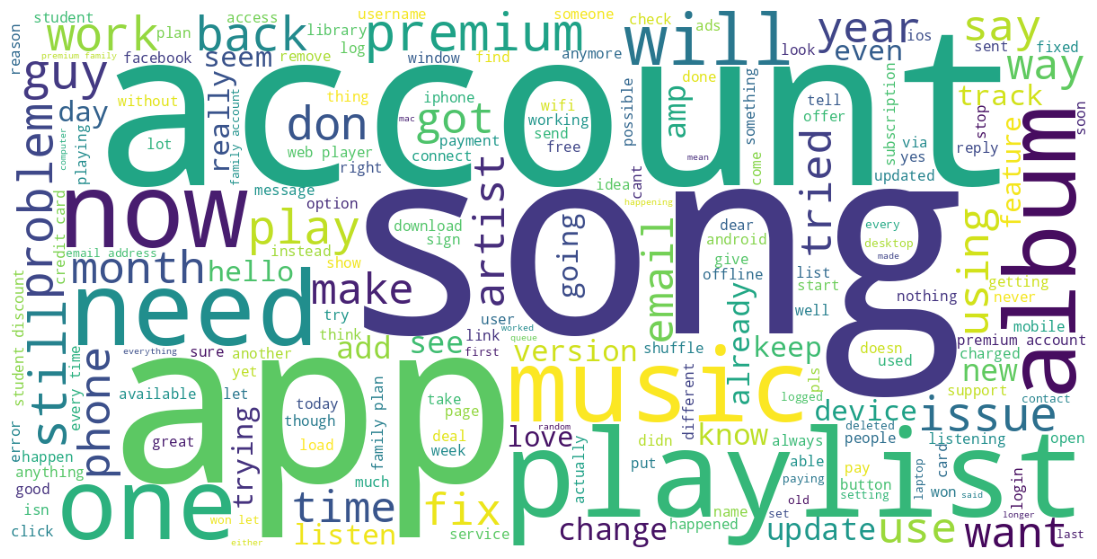

In [64]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(" ".join(filtered_words))

plt.figure(figsize=(14,7))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [65]:
intent_mapping = pd.DataFrame({
    "intent":[
        "Login Issue",
        "Premium Billing",
        "Playback Problem",
        "Playlist Issue",
        "Account Access",
        "Device Sync",
        "App Crash",
        "Refund Request",
        "Subscription Cancellation",
        "General Support"
    ],
    "description":[
        "Unable to log in",
        "Premium or payment issue",
        "Music playback problem",
        "Playlist issue",
        "Account access issue",
        "Device synchronization",
        "Application crash",
        "Refund request",
        "Cancel Premium",
        "Other requests"
    ]
})

intent_mapping.to_csv(
    "/content/drive/MyDrive/Hiver_Spotify_AI/evaluation/intent_mapping.csv",
    index=False
)

intent_mapping

,intent,description
0,Login Issue,Unable to log in
1,Premium Billing,Premium or payment issue
2,Playback Problem,Music playback problem
3,Playlist Issue,Playlist issue
4,Account Access,Account access issue
5,Device Sync,Device synchronization
6,App Crash,Application crash
7,Refund Request,Refund request
8,Subscription Cancellation,Cancel Premium
9,General Support,Other requests


In [66]:
conversation_pairs.to_csv(
    "/content/drive/MyDrive/Hiver_Spotify_AI/processed/conversation_pairs_cleaned.csv",
    index=False
)

print("Saved cleaned conversation pairs.")

Saved cleaned conversation pairs.


# Phase 5: Golden Evaluation Dataset

In [67]:
# Create a working copy
golden = conversation_pairs.copy()

# Keep only the columns we'll label
golden = golden[["customer_message"]]

# Empty columns for manual labeling
golden["intent"] = ""
golden["auto_or_escalate"] = ""

golden.head()

,customer_message,intent,auto_or_escalate
0,@115888 (3) their playlists bc ur algorithm ca...,,
1,@SpotifyCares Improvements haven't been notice...,,
2,@SpotifyCares before I already asked about if ...,,
3,@SpotifyCares There are so many issues that th...,,
4,@SpotifyCares For example in playlists I no lo...,,


In [68]:
keyword_groups = {
    "Login Issue": ["login", "password", "account", "sign"],
    "Premium Billing": ["premium", "payment", "charged", "subscription"],
    "Playback Problem": ["play", "music", "audio", "listen"],
    "Playlist Issue": ["playlist", "song"],
    "Account Access": ["email", "username"],
    "Device Sync": ["sync", "device"],
    "App Crash": ["crash", "bug", "freeze"],
    "Refund Request": ["refund"],
    "Subscription Cancellation": ["cancel"],
}

In [69]:
samples = []

for intent, keywords in keyword_groups.items():

    mask = conversation_pairs["clean_customer_message"].str.contains(
        "|".join(keywords),
        case=False,
        na=False
    )

    group = conversation_pairs[mask]

    if len(group) > 20:
        group = group.sample(20, random_state=42)

    group = group.copy()
    group["intent"] = ""
    group["auto_or_escalate"] = ""

    samples.append(group)

golden = pd.concat(samples, ignore_index=True)

print(golden.shape)
golden.head()

(180, 5)


,customer_message,spotify_reply,clean_customer_message,intent,auto_or_escalate
0,@SpotifyCares its is hooked to facebook which ...,"@153883 Hey there, help's here! Could you fire...",its is hooked to facebook which i do not have ...,,
1,@SpotifyCares trying to convert my account to ...,@383489 Hey there! Can you DM us your account'...,trying to convert my account to the student bu...,,
2,@SpotifyCares Hi have sent a message about an ...,"@208906 Hi, we've just replied to your DMs. We...",hi have sent a message about an issue with my ...,,
3,Anyone working @SpotifyCares today!! Can't use...,@389560 Hey! We've just sent you a DM 🙂 Let's ...,anyone working today can t use account but you...,,
4,"@SpotifyCares @SpotifyCares ah, I guess it’s b...",@132498 Hey there! Unfortunately we're unable ...,ah i guess it s because i ve revived n old acc...,,


In [70]:
golden.to_csv(
    "/content/drive/MyDrive/Hiver_Spotify_AI/evaluation/golden_dataset.csv",
    index=False
)

print("Golden dataset exported.")

Golden dataset exported.


# Phase 6: Semi-Automatic Golden Dataset Labeling

In [71]:
def suggest_intent(text):
    text = str(text).lower()

    if any(k in text for k in ["login", "password", "sign in", "log in"]):
        return "Login Issue"

    elif any(k in text for k in ["premium", "payment", "charged", "subscription"]):
        return "Premium Billing"

    elif any(k in text for k in ["playlist", "song"]):
        return "Playlist Issue"

    elif any(k in text for k in ["play", "playing", "music", "audio"]):
        return "Playback Problem"

    elif any(k in text for k in ["email", "username"]):
        return "Account Access"

    elif any(k in text for k in ["sync", "device"]):
        return "Device Sync"

    elif any(k in text for k in ["crash", "freeze", "bug"]):
        return "App Crash"

    elif "refund" in text:
        return "Refund Request"

    elif "cancel" in text:
        return "Subscription Cancellation"

    return "General Support"

In [72]:
def suggest_action(intent):
    escalation = {
        "Premium Billing",
        "Refund Request",
        "Account Access"
    }

    if intent in escalation:
        return "Escalate"

    return "Auto"

In [73]:
golden["intent"] = golden["clean_customer_message"].apply(suggest_intent)

golden["auto_or_escalate"] = golden["intent"].apply(suggest_action)

golden.head(15)

,customer_message,spotify_reply,clean_customer_message,intent,auto_or_escalate
0,@SpotifyCares its is hooked to facebook which ...,"@153883 Hey there, help's here! Could you fire...",its is hooked to facebook which i do not have ...,General Support,Auto
1,@SpotifyCares trying to convert my account to ...,@383489 Hey there! Can you DM us your account'...,trying to convert my account to the student bu...,General Support,Auto
2,@SpotifyCares Hi have sent a message about an ...,"@208906 Hi, we've just replied to your DMs. We...",hi have sent a message about an issue with my ...,General Support,Auto
3,Anyone working @SpotifyCares today!! Can't use...,@389560 Hey! We've just sent you a DM 🙂 Let's ...,anyone working today can t use account but you...,General Support,Auto
4,"@SpotifyCares @SpotifyCares ah, I guess it’s b...",@132498 Hey there! Unfortunately we're unable ...,ah i guess it s because i ve revived n old acc...,Playlist Issue,Auto
5,@SpotifyCares I have attempted to use the “rem...,@366083 Got it. Can you DM us your account's e...,i have attempted to use the remove headspace b...,General Support,Auto
6,"@SpotifyCares My premium account, suddenly tur...",@264904 Can you DM us your account's email add...,my premium account suddenly turn in to a free ...,Premium Billing,Escalate
7,"@SpotifyCares Hi team, I'm about to sign up to...",@255746 Hi Ray! Can you DM us your account's u...,hi team i m about to sign up to premium i woul...,Premium Billing,Escalate
8,@SpotifyCares My iPhone logged me out &amp; no...,@344258 Hey there! Could you DM us your Spotif...,my iphone logged me out now says my log in is ...,Login Issue,Auto
9,@SpotifyCares I have a question\nWhen I try to...,"@260508 Hey David, that's not cool! Could you ...",i have a question when i try to log in it says...,Login Issue,Auto


In [74]:
golden["intent"].value_counts()

,count
intent,
Premium Billing,48
Playlist Issue,37
Playback Problem,20
Account Access,17
Login Issue,15
Device Sync,11
App Crash,11
General Support,10
Refund Request,7


In [75]:
review_cases = golden[
    golden["intent"] == "General Support"
]

print("Needs manual review:", len(review_cases))

review_cases.head(20)

Needs manual review: 10


,customer_message,spotify_reply,clean_customer_message,intent,auto_or_escalate
0,@SpotifyCares its is hooked to facebook which ...,"@153883 Hey there, help's here! Could you fire...",its is hooked to facebook which i do not have ...,General Support,Auto
1,@SpotifyCares trying to convert my account to ...,@383489 Hey there! Can you DM us your account'...,trying to convert my account to the student bu...,General Support,Auto
2,@SpotifyCares Hi have sent a message about an ...,"@208906 Hi, we've just replied to your DMs. We...",hi have sent a message about an issue with my ...,General Support,Auto
3,Anyone working @SpotifyCares today!! Can't use...,@389560 Hey! We've just sent you a DM 🙂 Let's ...,anyone working today can t use account but you...,General Support,Auto
5,@SpotifyCares I have attempted to use the “rem...,@366083 Got it. Can you DM us your account's e...,i have attempted to use the remove headspace b...,General Support,Auto
10,@SpotifyCares Thanks. If I set the young 'uns ...,@344979 1: Sure thing! In order to use the Spo...,thanks if i set the young uns up with family a...,General Support,Auto
13,"@115888 my account randomly changed to ""9.99 s...",@318003 Hey there! Can you DM us your account'...,my account randomly changed to 9 99 spotify fo...,General Support,Auto
15,@Spotifycares Hi! I disabled FB integration on...,"@275690 Hey there! Don't worry, help's here. C...",hi i disabled fb integration on my spotify acc...,General Support,Auto
18,@SpotifyCares not signing up. Verification exp...,@257506 Hi there! We're afraid Spotify isn't a...,not signing up verification expires,General Support,Auto
52,"Dear @115888, What am I doing wrong that this ...",@186020 Hey there! Can you DM us your account'...,dear what am i doing wrong that this happens t...,General Support,Auto


In [76]:
golden.to_csv(
    "/content/drive/MyDrive/Hiver_Spotify_AI/evaluation/golden_dataset_suggested.csv",
    index=False
)

print("Suggested Golden Dataset exported.")

Suggested Golden Dataset exported.


In [77]:
# Inspect random conversation pairs
conversation_pairs.sample(15, random_state=42)[
    ["customer_message", "spotify_reply"]
]

,customer_message,spotify_reply
9038,"@115888 IDR4.990 for 3 months, really? 4.990...",@142364 Hey there! Could you send us a DM with...
2984,@SpotifyCares Done.,@325696 We've just sent you a DM 🙂/KL
10218,@SpotifyCares lol ... see? @GooglePlayMusic @1...,@306539 Can you tell us what's happening exact...
10871,@SpotifyCares I have tried in Chrome and IE. I...,@216046 We're afraid we don't have any other i...
10667,@SpotifyCares It's ridiculously slow. Sometime...,@364273 Got it. Does logging out &gt; restarti...
2054,@SpotifyCares I am getting a message that my p...,@368611 Hey there! Can you DM us your account'...
542,Is there a way I can stop you guys from puttin...,"@234222 Hey there! The more you use Spotify, t..."
8900,@SpotifyCares Hi there. Unfortunately it didn’...,@140436 Thanks for keeping us in the loop. Can...
1935,@SpotifyCares Yeah I do. I unplugged my router...,@296853 That's great news! Let us know if you ...
2995,Trying to add my family to Premium to Family p...,@329828 Hi Noel! Can you DM us the email addre...


In [78]:
print("Total pairs:", len(conversation_pairs))

print("Duplicate customer messages:",
      conversation_pairs["customer_message"].duplicated().sum())

print("Empty customer messages:",
      conversation_pairs["customer_message"].isna().sum())

print("Empty Spotify replies:",
      conversation_pairs["spotify_reply"].isna().sum())

Total pairs: 14269
Duplicate customer messages: 496
Empty customer messages: 0
Empty Spotify replies: 0


In [79]:
golden = pd.read_csv(
    "/content/drive/MyDrive/Hiver_Spotify_AI/evaluation/golden_dataset_labeled.csv"
)

golden["intent"].value_counts()

,count
intent,
Premium Billing,48
Playlist Issue,37
Playback Problem,20
Account Access,17
Login Issue,15
Device Sync,11
App Crash,11
General Support,10
Refund Request,6


In [80]:
!pip install -q sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 49.8 MB/s eta 0:00:00


In [81]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

In [82]:
model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [83]:
knowledge_texts = conversation_pairs["clean_customer_message"].tolist()

print("Knowledge Base Size:", len(knowledge_texts))

Knowledge Base Size: 14269


In [84]:
embeddings = model.encode(
    knowledge_texts,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(embeddings.shape)

Batches:   0%|          | 0/446 [00:00<?, ?it/s]

(14269, 384)


In [85]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("Vectors stored:", index.ntotal)

Vectors stored: 14269


In [86]:
faiss.write_index(
    index,
    "/content/drive/MyDrive/Hiver_Spotify_AI/models/spotify_faiss.index"
)

np.save(
    "/content/drive/MyDrive/Hiver_Spotify_AI/models/spotify_embeddings.npy",
    embeddings
)

print("Knowledge base saved.")

Knowledge base saved.


In [87]:
query = "My Premium payment failed."

query_embedding = model.encode([query], convert_to_numpy=True)

distances, indices = index.search(query_embedding, k=3)

for rank, idx in enumerate(indices[0], 1):
    print(f"\nResult {rank}")
    print("Customer:", conversation_pairs.iloc[idx]["customer_message"])
    print("Spotify :", conversation_pairs.iloc[idx]["spotify_reply"])


Result 1
Customer: @117153 my premium is not working and I paid a year in full last month?? Help! User name wes711
Spotify : @386119 @117153 Hey, we're happy to help! We've just replied to your DM. Let's continue chatting there /GT

Result 2
Customer: @SpotifyCares can you help? My premium account does not work even if it is regularly payed.
Spotify : @141625 Hey! This doesn't sound good. What issues are you having and on what device? We'll see what we can suggest /MX

Result 3
Customer: @SpotifyCares *psst* can you help me get my premium back, it won't let me update payments
Spotify : @376643 Hey there! We've just sent you a DM 🙂 /DF


In [154]:
import requests
from google.colab import userdata

OPENROUTER_API_KEY = userdata.get("OPEN")

def call_llm(prompt):

    response = requests.post(
        "https://openrouter.ai/api/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
            "Content-Type": "application/json",
            "HTTP-Referer": "https://colab.research.google.com",
            "X-OpenRouter-Title": "Hiver Spotify AI"
        },
        json={
            "model": "openrouter/free",
            "messages":[
                {
                    "role":"system",
                    "content":"You are Spotify's AI Support Assistant."
                },
                {
                    "role":"user",
                    "content":prompt
                }
            ]
        }
    )

    print("Status:", response.status_code)
    print(response.text)

    response.raise_for_status()

    return response.json()["choices"][0]["message"]["content"]

In [155]:
def build_prompt(query, retrieved):

    examples = ""

    for i, item in enumerate(retrieved, 1):
        examples += f"""
Example {i}
Customer Issue:
{clean_text(item['customer'])}

Support Resolution:
{clean_text(item['reply'])}
"""

    return f"""
You are an AI Customer Support Agent for Spotify inside Hiver.

Rules:
- Write naturally.
- Do NOT use Twitter mentions.
- Do NOT include t.co links.
- Do NOT use agent initials like /LM.
- If account verification is needed, ask the customer to continue securely via private support.
- Keep the reply between 2 and 5 sentences.

Customer Issue:
{query}

Historical Support Examples:
{examples}

Generate a professional support reply.
"""

In [156]:
import re
import html

def post_process_reply(reply):
    reply = html.unescape(reply)

    # Remove Twitter mentions
    reply = re.sub(r'@\w+', '', reply)

    # Remove Twitter short links
    reply = re.sub(r'https?://t\.co/\S+', '', reply)

    # Remove markdown links
    reply = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', reply)

    # Remove Spotify agent signatures (/LM, /JP)
    reply = re.sub(r'/[A-Z]{2,3}\b', '', reply)

    # Remove leftover brackets
    reply = reply.replace("(", "").replace(")", "")

    # Normalize spaces
    reply = re.sub(r'\s+', ' ', reply).strip()

    return reply

def generate_reply(query):

    cases = retrieve_cases(query)

    prompt = build_prompt(query, cases)

    reply = call_llm(prompt)

    reply = post_process_reply(reply)

    return reply, cases

In [157]:
reply, cases = generate_reply(
    "I paid for Premium but my subscription disappeared."
)

print(reply)

Status: 200

         

         

         

         

         
{"id":"gen-1789470233-NXdn6u69jjLx6azLiV1W","object":"chat.completion","created":1789470233,"model":"nex-agi/nex-n2.5-pro:free","provider":"Nex AGI","system_fingerprint":null,"service_tier":null,"choices":[{"index":0,"logprobs":null,"finish_reason":"stop","native_finish_reason":"stop","message":{"role":"assistant","content":"Hi, sorry to hear your Premium subscription disappeared after payment. Please continue via private support with the email address on your Spotify account and any receipt or payment confirmation you have. We’ll verify the account and check what happened.","refusal":null,"reasoning":"\nWe need answer as Spotify support assistant, 2-5 sentences, natural, no Twitter mentions, no t.co, no agent initials. Need address issue paid Premium subscription disappeared. Likely ask to continue via private support if verification needed. We need generate professional support reply. Maybe: \"Hi, sorry to hear your P